# Multidimensional Scaling: Visualizing Similarities among Cities

This Notebook applies Multidimensional Scaling (MDS) to visualize similarities among cities in a two-dimensional space.

# 多次元尺度構成法：都市間の類似度を2次元空間で可視化する

このNotebookでは、多次元尺度構成法（Multidimensional Scaling: MDS）を使って、複数の都市間の類似度を2次元空間に配置します。

## 1. Learning Objectives / 学習目標

- Understand the purpose of Multidimensional Scaling
- Understand similarities, dissimilarities, and distance matrices
- Standardize variables before calculating distances
- Calculate Euclidean distances among observations
- Understand Classical MDS
- Perform Metric MDS
- Interpret Stress
- Compare original distances with low-dimensional distances
- Interpret an MDS map
- Understand the difference between MDS and PCA

- 多次元尺度構成法の目的を理解する
- 類似度・非類似度・距離行列を理解する
- 距離計算前の標準化を理解する
- 都市間のユークリッド距離を計算する
- 古典的MDSの考え方を理解する
- Metric MDSを実行する
- Stressを理解する
- 元の距離と低次元空間上の距離を比較する
- MDSマップを解釈する
- MDSとPCAの違いを理解する

## 2. Use Case / ユースケース

A regional planning team wants to compare several cities using multiple urban indicators.

The cities differ in:

- population density
- income
- public transportation
- green space
- housing costs
- digital infrastructure

Instead of examining all indicators separately, the team wants a map where similar cities appear close together and dissimilar cities appear far apart.

ある地域政策チームでは、複数の都市をさまざまな都市指標から比較したいと考えています。

人口密度、所得、公共交通、緑地、住宅費、デジタルインフラなどを個別に比較するだけでなく、

> 特徴が似ている都市は近く、異なる都市は遠く

なるような2次元マップを作成します。

## 3. What Is Multidimensional Scaling? / 多次元尺度構成法とは

Multidimensional Scaling starts from **distances or dissimilarities** among observations.

The objective is to find coordinates in a low-dimensional space that preserve those original distances as well as possible.

If two cities are very similar, MDS tries to place them close together.

If two cities are very different, MDS tries to place them far apart.

多次元尺度構成法では、対象間の**距離または非類似度**を出発点にします。

その距離関係をできるだけ保ちながら、対象を2次元や3次元の低次元空間に配置します。

似た都市は近く、異なる都市は遠くに配置されることを目指します。

## 4. MDS and PCA / MDSとPCAの違い

Both methods can create low-dimensional visualizations, but their starting points differ.

| PCA | MDS |
|---|---|
| Starts from original variables | Starts from distances / dissimilarities |
| Preserves variance | Preserves relative distances |
| Axes have loading-based interpretations | Axes themselves often have no direct meaning |
| Mainly numerical feature data | Can also use externally defined distances |

どちらも低次元可視化に使えますが、出発点が異なります。

| 主成分分析 | MDS |
|---|---|
| 元の変数から始める | 距離・非類似度から始める |
| 分散をできるだけ保持する | 距離関係をできるだけ保持する |
| 主成分負荷量から軸を解釈できる | 軸そのものに明確な意味がないことが多い |
| 主に数値変数 | 外部で定義した距離も利用可能 |

## 5. Import Libraries / ライブラリの読み込み

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.manifold import MDS
from sklearn.metrics import pairwise_distances
from sklearn.preprocessing import StandardScaler

pd.set_option("display.max_columns", None)

## 6. Load the Dataset / データの読み込み

In [2]:
candidate_paths = [
    Path("../data/city_characteristics.csv"),
    Path("09_multidimensional_scaling/data/city_characteristics.csv"),
    Path("data/city_characteristics.csv"),
]

data_path = next((p for p in candidate_paths if p.exists()), None)

if data_path is None:
    raise FileNotFoundError("city_characteristics.csv was not found.")

df = pd.read_csv(data_path)
df

,city,population_density,median_income,public_transit_score,green_space_ratio,housing_cost_index,digital_infrastructure_score
0,Harbor City,8200,72,82,18,118,86
1,Metroville,10400,78,91,12,134,93
2,Greenfield,2400,58,44,42,82,58
3,Riverside,3600,61,56,34,91,65
4,Techport,9100,84,88,16,129,98
5,Hilltown,1800,55,35,51,74,49
6,Sunbay,4200,66,62,29,102,72
7,Oldtown,5100,60,69,24,96,61
8,Lakeside,2800,63,48,45,88,57
9,Northgate,7600,70,79,21,112,83


## 7. Understand the Dataset / データの理解

In [3]:
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")
df.info()

Rows: 10
Columns: 7
<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 7 columns):
 #   Column                        Non-Null Count  Dtype
---  ------                        --------------  -----
 0   city                          10 non-null     str  
 1   population_density            10 non-null     int64
 2   median_income                 10 non-null     int64
 3   public_transit_score          10 non-null     int64
 4   green_space_ratio             10 non-null     int64
 5   housing_cost_index            10 non-null     int64
 6   digital_infrastructure_score  10 non-null     int64
dtypes: int64(6), str(1)
memory usage: 692.0 bytes


In [4]:
df.isna().sum()

city                            0
population_density              0
median_income                   0
public_transit_score            0
green_space_ratio               0
housing_cost_index              0
digital_infrastructure_score    0
dtype: int64

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
population_density,10.0,5520.0,3068.043169,1800.0,3000.00,4650.0,8050.00,10400.0
median_income,10.0,66.7,9.250225,55.0,60.25,64.5,71.50,84.0
public_transit_score,10.0,65.4,19.506124,35.0,50.00,65.5,81.25,91.0
green_space_ratio,10.0,29.2,13.339998,12.0,18.75,26.5,40.00,51.0
housing_cost_index,10.0,102.6,20.117433,74.0,88.75,99.0,116.50,134.0
digital_infrastructure_score,10.0,72.2,16.844386,49.0,58.75,68.5,85.25,98.0


## 8. Select Features / 分析対象変数の選択

The city name is an identifier, so it is excluded from distance calculation.

都市名は識別用項目なので、距離計算には使用しません。

In [6]:
features = [
    "population_density",
    "median_income",
    "public_transit_score",
    "green_space_ratio",
    "housing_cost_index",
    "digital_infrastructure_score",
]

X = df[features].copy()
X.head()

,population_density,median_income,public_transit_score,green_space_ratio,housing_cost_index,digital_infrastructure_score
0,8200,72,82,18,118,86
1,10400,78,91,12,134,93
2,2400,58,44,42,82,58
3,3600,61,56,34,91,65
4,9100,84,88,16,129,98


## 9. Why Standardization Matters / なぜ標準化が必要か

Population density may be measured in thousands, while green-space ratio is a percentage.

Without standardization, variables with large numerical scales would dominate Euclidean distance.

人口密度は数千単位、緑地率はパーセントです。

標準化をしないと、数値スケールが大きい変数が距離計算を支配してしまいます。

In [7]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

scaled_df = pd.DataFrame(
    X_scaled,
    index=df["city"],
    columns=features,
)

scaled_df.round(2)

,population_density,median_income,public_transit_score,green_space_ratio,housing_cost_index,digital_infrastructure_score
city,,,,,,
Harbor City,0.92,0.60,0.90,-0.88,0.81,0.86
Metroville,1.68,1.29,1.38,-1.36,1.65,1.30
Greenfield,-1.07,-0.99,-1.16,1.01,-1.08,-0.89
Riverside,-0.66,-0.65,-0.51,0.38,-0.61,-0.45
Techport,1.23,1.97,1.22,-1.04,1.38,1.61
Hilltown,-1.28,-1.33,-1.64,1.72,-1.50,-1.45
Sunbay,-0.45,-0.08,-0.18,-0.02,-0.03,-0.01
Oldtown,-0.14,-0.76,0.19,-0.41,-0.35,-0.70
Lakeside,-0.93,-0.42,-0.94,1.25,-0.76,-0.95


## 10. Calculate the Distance Matrix / 距離行列を計算する

We calculate Euclidean distances between every pair of cities after standardization.

A distance of zero means the same observation. Larger values indicate greater dissimilarity.

標準化後の都市間について、すべての組み合わせのユークリッド距離を計算します。

距離が小さいほど似ており、大きいほど異なります。

In [8]:
distance_matrix = pairwise_distances(
    X_scaled,
    metric="euclidean",
)

distance_df = pd.DataFrame(
    distance_matrix,
    index=df["city"],
    columns=df["city"],
)

distance_df.round(2)

city,Harbor City,Metroville,Greenfield,Riverside,Techport,Hilltown,Sunbay,Oldtown,Lakeside,Northgate
city,,,,,,,,,,
Harbor City,0.00,1.55,4.58,3.37,1.73,5.70,2.40,2.74,4.26,0.56
Metroville,1.55,0.00,6.09,4.89,0.98,7.19,3.90,4.22,5.73,2.10
Greenfield,4.58,6.09,0.00,1.23,6.02,1.18,2.25,2.31,0.74,4.04
Riverside,3.37,4.89,1.23,0.00,4.87,2.40,1.07,1.24,1.16,2.83
Techport,1.73,0.98,6.02,4.87,0.00,7.13,3.84,4.38,5.62,2.21
Hilltown,5.70,7.19,1.18,2.40,7.13,0.00,3.41,3.38,1.57,5.16
Sunbay,2.40,3.90,2.25,1.07,3.84,3.41,0.00,1.20,1.98,1.89
Oldtown,2.74,4.22,2.31,1.24,4.38,3.38,1.20,0.00,2.24,2.23
Lakeside,4.26,5.73,0.74,1.16,5.62,1.57,1.98,2.24,0.00,3.74


## 11. Visualize the Distance Matrix / 距離行列を可視化する

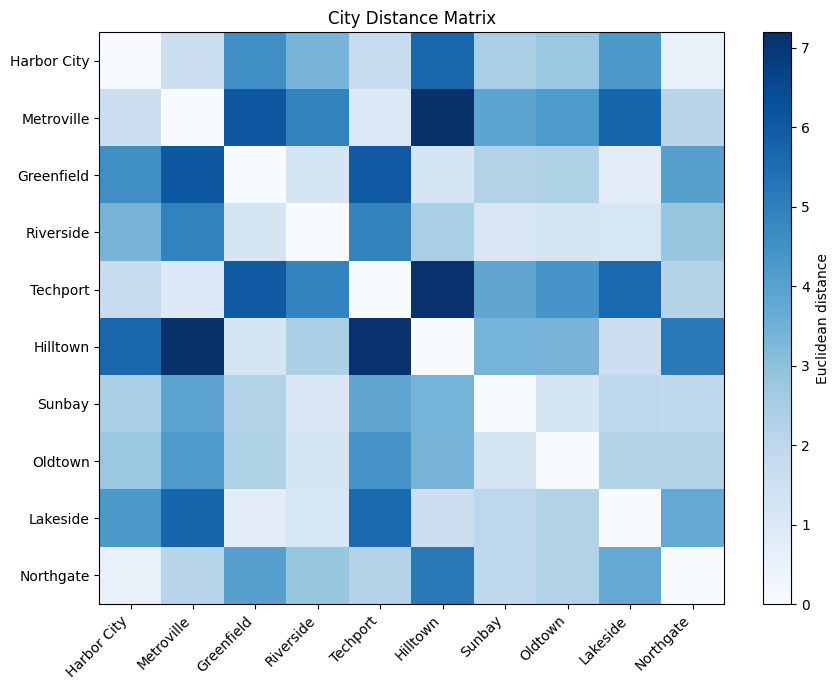

In [9]:
fig, ax = plt.subplots(figsize=(9, 7))

image = ax.imshow(
    distance_df.values,
    aspect="auto",
    cmap="Blues",
)

ax.set_xticks(
    range(len(distance_df.columns)),
    labels=distance_df.columns,
    rotation=45,
    ha="right",
)

ax.set_yticks(
    range(len(distance_df.index)),
    labels=distance_df.index,
)

fig.colorbar(image, ax=ax, label="Euclidean distance")
ax.set_title("City Distance Matrix")
plt.tight_layout()
plt.show()

## 12. Find the Most Similar and Dissimilar Pairs / 最も似た都市・異なる都市を確認する

Before dimensionality reduction, inspect the smallest and largest pairwise distances.

MDS should approximately preserve these relationships in the final map.

次元削減前に、最も近い都市ペアと最も遠い都市ペアを確認します。

MDSのマップでも、これらの関係がおおむね維持されることを期待します。

In [10]:
pairs = []

for i in range(len(df)):
    for j in range(i + 1, len(df)):
        pairs.append({
            "city_1": df.loc[i, "city"],
            "city_2": df.loc[j, "city"],
            "distance": distance_matrix[i, j],
        })

pair_df = pd.DataFrame(pairs)

print("Most similar pairs")
display(pair_df.nsmallest(5, "distance").round(3))

print("Most dissimilar pairs")
display(pair_df.nlargest(5, "distance").round(3))

Most similar pairs


,city_1,city_2,distance
8,Harbor City,Northgate,0.558
22,Greenfield,Lakeside,0.741
11,Metroville,Techport,0.980
26,Riverside,Sunbay,1.074
28,Riverside,Lakeside,1.160


Most dissimilar pairs


,city_1,city_2,distance
12,Metroville,Hilltown,7.192
30,Techport,Hilltown,7.125
9,Metroville,Greenfield,6.086
18,Greenfield,Techport,6.023
15,Metroville,Lakeside,5.729


## 13. Classical MDS / 古典的MDS

Classical MDS reconstructs coordinates from a distance matrix using eigenvalue decomposition.

The core steps are:

1. square the distance matrix
2. double-center it
3. perform eigenvalue decomposition
4. construct coordinates from positive eigenvalues

古典的MDSでは、距離行列から固有値分解を使って座標を復元します。

距離の二乗行列を二重中心化し、その行列を固有値分解して低次元座標を求めます。

In [11]:
D2 = distance_matrix ** 2
n = D2.shape[0]

J = np.eye(n) - np.ones((n, n)) / n

B = -0.5 * J @ D2 @ J

eigenvalues, eigenvectors = np.linalg.eigh(B)

order = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[order]
eigenvectors = eigenvectors[:, order]

print("Eigenvalues:")
print(np.round(eigenvalues, 4))

Eigenvalues:
[ 5.72361e+01  2.08190e+00  3.68400e-01  2.02500e-01  8.99000e-02
  2.11000e-02  0.00000e+00 -0.00000e+00 -0.00000e+00 -0.00000e+00]


## 14. Classical MDS Coordinates / 古典的MDSの座標

Only positive eigenvalues contribute to real Euclidean coordinates.

For a two-dimensional representation, we use the two largest positive eigenvalues.

正の固有値だけが実数のユークリッド座標に寄与します。

2次元表示では、最も大きい2つの正の固有値を使用します。

In [12]:
positive = eigenvalues > 1e-10

positive_eigenvalues = eigenvalues[positive]
positive_eigenvectors = eigenvectors[:, positive]

classical_coordinates = (
    positive_eigenvectors[:, :2]
    * np.sqrt(positive_eigenvalues[:2])
)

classical_df = pd.DataFrame(
    classical_coordinates,
    index=df["city"],
    columns=["Dim1", "Dim2"],
)

classical_df.round(3)

,Dim1,Dim2
city,,
Harbor City,-2.034,-0.200
Metroville,-3.537,-0.072
Greenfield,2.532,0.090
Riverside,1.329,-0.148
Techport,-3.450,0.741
Hilltown,3.644,0.262
Sunbay,0.306,0.047
Oldtown,0.549,-1.030
Lakeside,2.150,0.527


## 15. Explained Representation / 2次元で表現できる割合

For Classical MDS with Euclidean distances, the positive eigenvalues can be used to summarize how much of the distance geometry is represented by each dimension.

古典的MDSでは、正の固有値を使って各次元が距離構造をどの程度表しているか確認できます。

In [13]:
explained = (
    positive_eigenvalues
    / positive_eigenvalues.sum()
)

explained_df = pd.DataFrame({
    "dimension": [
        f"Dim{i+1}"
        for i in range(len(explained))
    ],
    "proportion": explained,
    "cumulative": np.cumsum(explained),
})

explained_df.round(4)

,dimension,proportion,cumulative
0,Dim1,0.9539,0.9539
1,Dim2,0.0347,0.9886
2,Dim3,0.0061,0.9948
3,Dim4,0.0034,0.9981
4,Dim5,0.0015,0.9996
5,Dim6,0.0004,1.0000


## 16. Classical MDS Map / 古典的MDSマップ

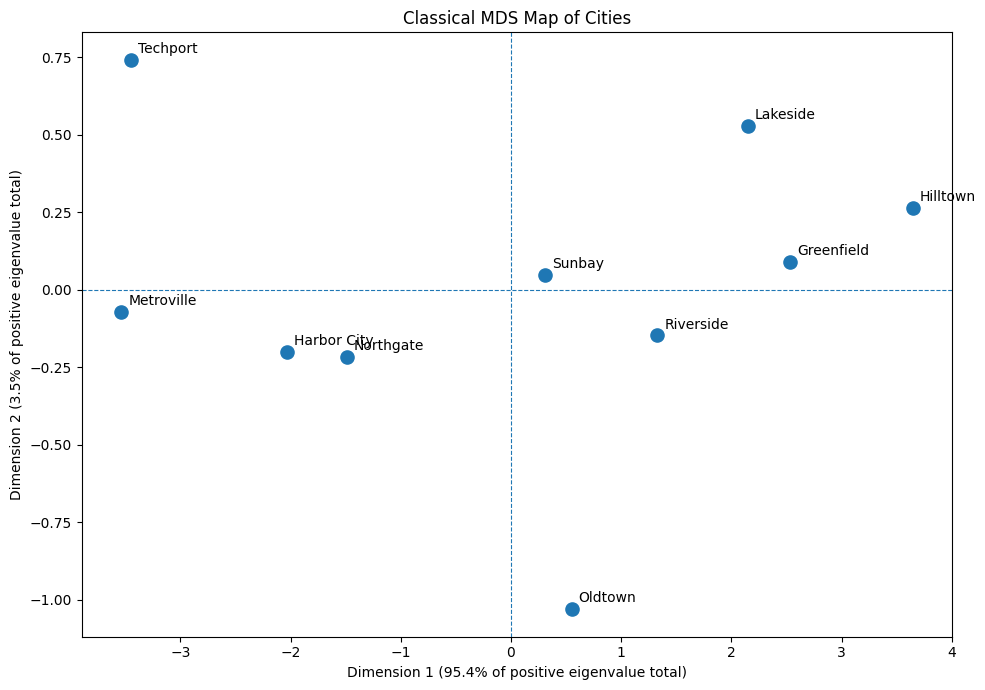

In [14]:
plt.figure(figsize=(10, 7))

plt.scatter(
    classical_df["Dim1"],
    classical_df["Dim2"],
    s=90,
)

for city, row in classical_df.iterrows():
    plt.annotate(
        city,
        (row["Dim1"], row["Dim2"]),
        xytext=(5, 5),
        textcoords="offset points",
    )

plt.axhline(0, linestyle="--", linewidth=0.8)
plt.axvline(0, linestyle="--", linewidth=0.8)

plt.xlabel(
    f"Dimension 1 ({explained[0]*100:.1f}% of positive eigenvalue total)"
)
plt.ylabel(
    f"Dimension 2 ({explained[1]*100:.1f}% of positive eigenvalue total)"
)

plt.title("Classical MDS Map of Cities")
plt.tight_layout()
plt.show()

## 17. Metric MDS / Metric MDSを実行する

We also apply iterative Metric MDS using scikit-learn.

Metric MDS searches for coordinates that minimize disagreement between:

- original dissimilarities
- distances in the low-dimensional configuration

scikit-learnを使って、反復計算によるMetric MDSも実行します。

元の距離と低次元空間上の距離のずれが小さくなるように座標を探索します。

In [15]:
mds = MDS(
    n_components=2,
    metric=True,
    dissimilarity="precomputed",
    random_state=42,
    n_init=8,
    max_iter=1000,
    eps=1e-6,
)

mds_coordinates = mds.fit_transform(distance_matrix)

mds_df = pd.DataFrame(
    mds_coordinates,
    index=df["city"],
    columns=["Dim1", "Dim2"],
)

mds_df.round(3)

e:\Analytics\Multivariate-Analytics\.venv\Lib\site-packages\sklearn\manifold\_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
e:\Analytics\Multivariate-Analytics\.venv\Lib\site-packages\sklearn\manifold\_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(
e:\Analytics\Multivariate-Analytics\.venv\Lib\site-packages\sklearn\manifold\_mds.py:779: FutureWarning: Use metric_mds=True instead of metric=True. The support for metric={True/False} will be dropped in 1.10.
  warnings.warn(


,Dim1,Dim2
city,,
Harbor City,-1.975,-0.516
Metroville,-3.433,-0.961
Greenfield,2.406,0.826
Riverside,1.206,0.583
Techport,-3.017,-1.856
Hilltown,3.562,0.906
Sunbay,0.313,0.033
Oldtown,0.171,1.194
Lakeside,2.231,0.123


## 18. Metric MDS Map / Metric MDSマップ

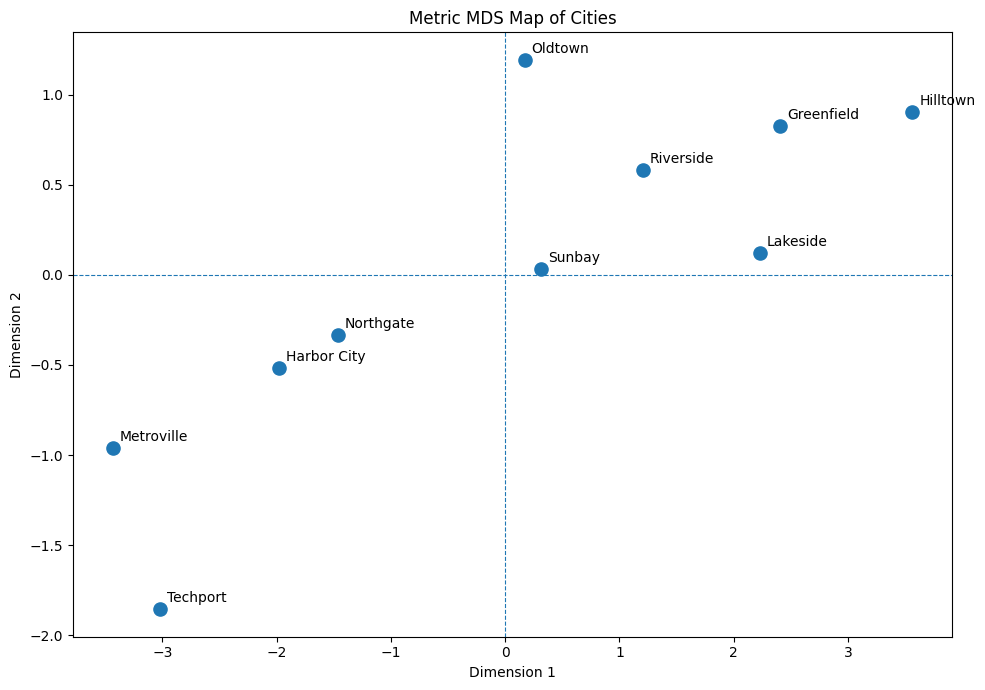

In [16]:
plt.figure(figsize=(10, 7))

plt.scatter(
    mds_df["Dim1"],
    mds_df["Dim2"],
    s=90,
)

for city, row in mds_df.iterrows():
    plt.annotate(
        city,
        (row["Dim1"], row["Dim2"]),
        xytext=(5, 5),
        textcoords="offset points",
    )

plt.axhline(0, linestyle="--", linewidth=0.8)
plt.axvline(0, linestyle="--", linewidth=0.8)

plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.title("Metric MDS Map of Cities")
plt.tight_layout()
plt.show()

## 19. Stress / Stressによる適合度評価

Stress measures how much the low-dimensional distances differ from the original dissimilarities.

Smaller values indicate a better representation.

Because raw Stress depends on the scale and implementation, we also calculate **normalized Stress-1**:

`Stress-1 = sqrt( sum((d_ij - dhat_ij)^2) / sum(d_ij^2) )`

Stressは、元の距離と低次元空間上の距離のずれを表します。

値が小さいほど、元の距離構造をよく再現できています。

ここでは比較しやすいように正規化したStress-1も計算します。

In [17]:
embedded_distances = pairwise_distances(
    mds_coordinates,
    metric="euclidean",
)

upper = np.triu_indices_from(
    distance_matrix,
    k=1,
)

original_values = distance_matrix[upper]
embedded_values = embedded_distances[upper]

stress_1 = np.sqrt(
    np.sum(
        (original_values - embedded_values) ** 2
    )
    / np.sum(original_values ** 2)
)

print(f"scikit-learn raw stress: {mds.stress_:.4f}")
print(f"Normalized Stress-1:    {stress_1:.4f}")

scikit-learn raw stress: 0.0407
Normalized Stress-1:    0.0082


## 20. Shepard Plot / Shepardプロット

A Shepard plot compares original dissimilarities with distances in the MDS map.

If the two-dimensional representation is good, the points should lie close to the diagonal line.

Shepardプロットでは、元の距離とMDS空間上の距離を比較します。

2次元表現が良ければ、点は対角線の近くに並びます。

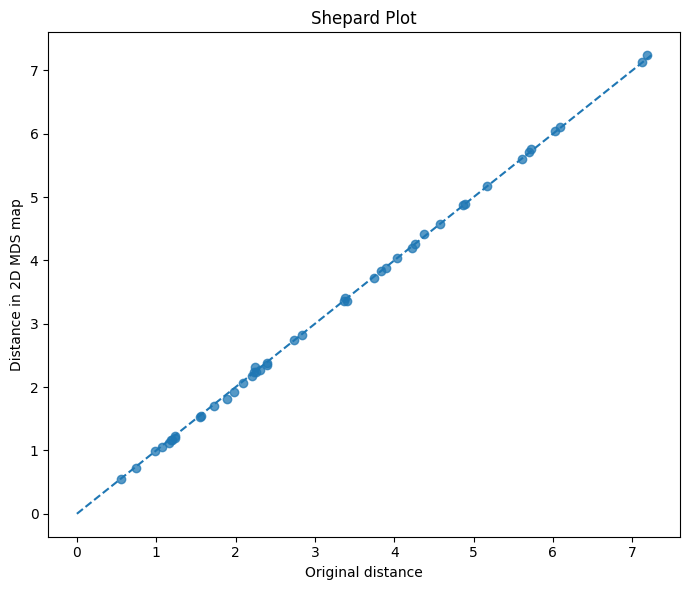

In [18]:
plt.figure(figsize=(7, 6))

plt.scatter(
    original_values,
    embedded_values,
    alpha=0.75,
)

max_value = max(
    original_values.max(),
    embedded_values.max(),
)

plt.plot(
    [0, max_value],
    [0, max_value],
    linestyle="--",
)

plt.xlabel("Original distance")
plt.ylabel("Distance in 2D MDS map")
plt.title("Shepard Plot")
plt.tight_layout()
plt.show()

## 21. Correlation between Original and Embedded Distances / 距離の相関

Another simple diagnostic is the correlation between original pairwise distances and the distances in the MDS representation.

This correlation is not a substitute for Stress, but it provides an intuitive summary.

元の距離とMDS空間上の距離の相関も確認します。

これはStressの代替ではありませんが、距離関係がどの程度維持されているかを直感的に把握できます。

In [19]:
distance_correlation = np.corrcoef(
    original_values,
    embedded_values,
)[0, 1]

print(
    f"Correlation between original and embedded distances: "
    f"{distance_correlation:.3f}"
)

Correlation between original and embedded distances: 1.000


## 22. Interpret the City Map / 都市マップを解釈する

The most important principle is:

> Interpret **relative distances**, not the absolute meaning of the axes.

MDS configurations can be rotated or reflected without changing their distance structure.

For example:

- cities close together have similar multivariate urban characteristics
- cities far apart have more different characteristics
- groups of nearby cities may suggest natural city types

MDSで最も重要なのは、

> 軸そのものではなく、都市間の相対的な距離を見る

ことです。

MDSの配置は回転・反転しても距離関係は変わらないため、「第1軸は必ず経済力」といった固定的な意味づけは通常行いません。

近い都市ほど総合的な都市特性が似ており、遠い都市ほど異なります。

## 23. Inspect Nearby Cities in the Map / MDS空間で近い都市を確認する

Calculate distances again using the two-dimensional MDS coordinates and compare the nearest pairs with the original distance matrix.

2次元MDS空間上で再び距離を計算し、元の距離行列と近い関係が保たれているか確認します。

In [20]:
mds_distance_matrix = pairwise_distances(
    mds_coordinates,
    metric="euclidean",
)

mds_pairs = []

for i in range(len(df)):
    for j in range(i + 1, len(df)):
        mds_pairs.append({
            "city_1": df.loc[i, "city"],
            "city_2": df.loc[j, "city"],
            "original_distance": distance_matrix[i, j],
            "mds_distance": mds_distance_matrix[i, j],
        })

mds_pair_df = pd.DataFrame(mds_pairs)

mds_pair_df.nsmallest(
    8,
    "mds_distance",
).round(3)

,city_1,city_2,original_distance,mds_distance
8,Harbor City,Northgate,0.558,0.543
22,Greenfield,Lakeside,0.741,0.725
11,Metroville,Techport,0.980,0.987
26,Riverside,Sunbay,1.074,1.050
28,Riverside,Lakeside,1.160,1.123
19,Greenfield,Hilltown,1.181,1.159
39,Sunbay,Oldtown,1.198,1.170
27,Riverside,Oldtown,1.236,1.202


## 24. Interpretation of This Dataset / 今回のデータの解釈

The educational dataset was designed to contain several broad urban patterns:

- Metroville, Techport, Harbor City, and Northgate have relatively urban and infrastructure-intensive profiles.
- Greenfield, Hilltown, and Lakeside have lower density and more green space.
- Riverside and Sunbay tend to occupy intermediate positions.
- Oldtown combines moderate density and transit access with relatively modest economic indicators.

The MDS map should reflect these similarities through relative distances.

今回の学習用データには、次のような都市特性を持たせています。

- Metroville、Techport、Harbor City、Northgateは都市型・インフラ型の特徴が強い
- Greenfield、Hilltown、Lakesideは人口密度が低く、緑地が多い
- Riverside、Sunbayはその中間的な特徴を持つ
- Oldtownは中程度の人口密度や交通利便性を持ちながら、経済指標は比較的控えめ

MDSマップでは、こうした類似性が都市間の距離として表現されます。

## 25. Assumptions and Limitations / 前提条件と限界

Important considerations include:

- Results depend heavily on how distance or dissimilarity is defined.
- Variables should usually be standardized when their scales differ.
- Two-dimensional representations inevitably lose some information.
- MDS axes generally do not have intrinsic meanings.
- The configuration may rotate or reflect across different implementations or random starts.
- Outliers can strongly affect pairwise distances.
- Stress should be checked before interpreting the map.
- Metric MDS assumes that numerical dissimilarities themselves are meaningful.
- This dataset is simulated for educational purposes.

主な注意点は次のとおりです。

- 結果は距離・非類似度の定義に大きく依存する。
- 単位が異なる変数では通常、標準化が必要になる。
- 2次元化すると必ず一部の情報が失われる。
- MDSの軸自体には通常、固有の意味はない。
- 実装や初期値によって配置が回転・反転する場合がある。
- 外れ値は距離に強く影響する。
- マップを解釈する前にStressを確認する。
- Metric MDSでは距離値そのものに意味があることを前提とする。
- 今回は学習用のシミュレーションデータである。

## 26. Conclusion / まとめ

This Notebook used Multidimensional Scaling to visualize similarities among cities.

The workflow was:

1. Load multivariate city characteristics
2. Standardize the variables
3. Calculate a distance matrix
4. Inspect similar and dissimilar city pairs
5. Perform Classical MDS
6. Perform Metric MDS
7. Evaluate the two-dimensional representation using Stress
8. Create a Shepard plot
9. Compare original and embedded distances
10. Interpret relative city positions

MDS is especially useful when the analytical question is:

> Can relationships expressed as distances or dissimilarities be represented in a small number of dimensions?

このNotebookでは、都市特性から作成した距離行列にMDSを適用し、都市間の類似関係を2次元空間へ可視化しました。

MDSは、

> 距離・非類似度として表現された対象間の関係を、少数の次元で可視化できるか

という問いに適した手法です。